In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE 

In [147]:
data = pd.read_csv('fraud_data (1).csv')  # Place dataset in working directory

In [148]:

# Step 2: Explore Dataset
print("Dataset Head:")
print(data.head())

print("\nDataset Describe:")
print(data.describe())
print("\nis_fraud Value Counts:")
print(data['is_fraud'].value_counts())

# Step 3: Data Preprocessing
# Inspect original data before any changes
print("\nOriginal data shape:", data.shape)
print("Original 'is_fraud' unique values:", data['is_fraud'].unique())

# Handle missing values (drop rows with NaNs in any column, including target) - do this early
data = data.dropna()
print("Data shape after dropna:", data.shape)

# Encode categorical variables (skip the target column)
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    if col != 'is_fraud':
        data[col] = le.fit_transform(data[col])

# Handle the target variable ('is_fraud')
# If already numeric/binary, convert to int
if data['is_fraud'].dtype in ['int64', 'float64'] and set(data['is_fraud'].dropna().unique()).issubset({0, 1}):
    print("Target is already binary. Converting to int.")
    data['is_fraud'] = data['is_fraud'].astype(int)
else:
    # Map based on actual values (update this dict after checking unique values above)
    # Examples: {'No': 0, 'Yes': 1} or {'Not Fraud': 0, 'Fraud': 1} or {'0': 0, '1': 1}
    mapping = {'No': 0, 'Yes': 1}  # Adjust based on your data's unique values!
    data['is_fraud'] = data['is_fraud'].map(mapping)
    
    # Drop rows where mapping failed (is_fraud is NaN)
    data = data.dropna(subset=['is_fraud'])
    data['is_fraud'] = data['is_fraud'].astype(int)

print("Data shape after target processing:", data.shape)
print("Target unique values after processing:", data['is_fraud'].unique())

# Final validation
if data.empty or data['is_fraud'].isna().sum() > 0 or not set(data['is_fraud'].unique()).issubset({0, 1}):
    raise ValueError("Dataset is empty or target is invalid. Check original unique values and adjust mapping.")

# Now separate features and target (after all drops)
features = data.drop('is_fraud', axis=1)
print("Features shape:", features.shape)
print("Target shape:", data['is_fraud'].shape)

# Handle infinities/large values in features
features.replace([np.inf, -np.inf], np.nan, inplace=True)
features.fillna(features.mean(), inplace=True)
features = np.clip(features, -1e10, 1e10)

# Feature scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns=features.columns)

# Final checks
print("Features_scaled shape:", features_scaled.shape)
print("Target shape for SMOTE:", data['is_fraud'].shape)

# Step 4: Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(features_scaled, data['is_fraud'])
print("\nAfter SMOTE - X_resampled shape:", X_resampled.shape)
print("y_resampled value counts:", pd.Series(y_resampled).value_counts())

Dataset Head:
       amount  oldbalanceOrg  newbalanceOrig  is_fraud
0   88.976286    1194.035017      756.721141         0
1   73.615056     913.708871      958.631445         0
2  120.611612     830.179030     1021.108797         0
3   86.567533    1167.430897      869.720502         0
4  112.120199     838.840069      529.253552         0

Dataset Describe:
            amount  oldbalanceOrg  newbalanceOrig     is_fraud
count  5000.000000    5000.000000     5000.000000  5000.000000
mean    149.366738    1059.124258      904.667597     0.010000
std     497.535132     659.087072      221.621415     0.099509
min      35.174653     215.519950     -653.959560     0.000000
25%      86.970728     865.495696      766.390841     0.000000
50%     100.450967     998.483021      902.907609     0.000000
75%     113.681079    1139.536747     1037.222343     0.000000
max    6537.854951   11710.634365     3824.167009     1.000000

is_fraud Value Counts:
0    4950
1      50
Name: is_fraud, dtype: int

In [150]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(features_scaled, data['is_fraud'])

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [152]:
# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


In [153]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0
XGBoost Accuracy: 1.0

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       998
           1       1.00      1.00      1.00       982

    accuracy                           1.00      1980
   macro avg       1.00      1.00      1.00      1980
weighted avg       1.00      1.00      1.00      1980



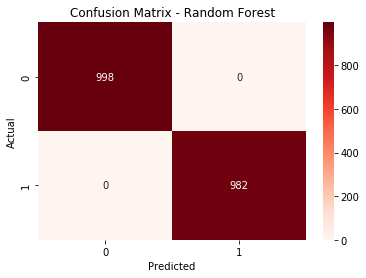

In [154]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [155]:
# ROC-AUC Score
roc = roc_auc_score(y_test, y_pred_rf)
print("Random Forest ROC-AUC Score:", roc) 

Random Forest ROC-AUC Score: 1.0
